Nome: Brendon Erick Euzebio Rus Peres

RA: 256130

Curso: Mestrado em Engenharia Elétrica


# Descrição do Problema

O problema consiste em descobrir a quantia em dinheiro a partir uma imagem. A imagem precisa ser de "topo", vista de cima. E preferencialmente a partir de uma câmera fixa, pois conforme se muda a distãncia entre as moedas e a câmera, a soma pode dar errado, pois o parâmetro para definição do valor de cada moeda é sua área ocupada na imagem.

Por exemplo, uma moeda de 1 real, se distanciada da câmera pode representar a área da moeda de 50 centavos, dessa forma, o algoritmo a classificará como uma moeda de 50 centavos, e não de 1 real.

# Solução

## Importação das bibliotecas e leitura da imagem.

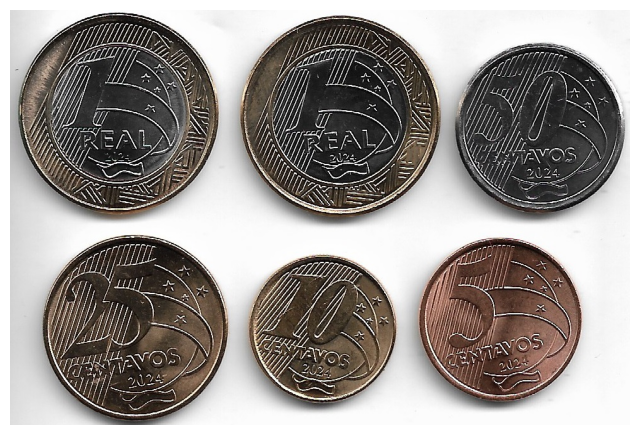

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

filename = "moedas.jpg"

plt.figure(figsize=(8, 6))
plt.axis('off')
img = mpimg.imread(filename)
plt.imshow(img)
plt.show()

A função $\texttt{cv2.morphologyEx}$ é uma função "faz-tudo" do OpenCV. Dependendo do parâmetro que você passa pra ela (como $\texttt{MORPH_CLOSE}$ ou $\texttt{MORPH_OPEN}$), ela executa um truque matemático diferente usando o seu kernel.

O parâmetro Morph_Close é a combinação sequencial de duas operações: primeiro uma dilatação, seguida de uma erosão aplicadas ao objeto principal da imagem. Ele une as regras desses dois métodos básicos e é utilizado principalmente para remover ruídos (no contexto prático, para preencher pequenas falhas ou "buracos" dentro dos objetos)

O parâmetro Morph_Open é a combinação sequencial de uma erosão seguida por uma dilatação aplicadas ao objeto da imagem. Assim como o fechamento, ela une as regras desses dois métodos principais, mas sua ordem invertida a torna ideal para remover ruídos (no contexto prático, serve para "apagar" pontinhos indesejados e sujeiras no fundo da imagem).

Referência: https://www.geeksforgeeks.org/python/python-opencv-morphological-operations/

In [ ]:
def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    kernel_op = np.ones((k_op, k_op), np.uint8)

    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1); plt.imshow(binr, cmap='gray'); plt.title("Binarização$_{Otsu}$"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(close, cmap='gray'); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(open, cmap='gray'); plt.axis('off')
    plt.show()

    return open

## Obtenção da quantia em dinheiro.

A função $\texttt{calc_npixels_label}$ serve, basicamente, para medir o tamanho de cada objeto (no caso, as moedas) na imagem, contando quantos pixels pertencem a cada um.

Ela recebe uma matriz onde cada moeda já está identificada com um número diferente. A partir disso, percorre esses identificadores (ignorando o fundo da imagem) e, para cada moeda, conta quantos pixels fazem parte dela.

No final, a função retorna uma lista com a área de cada moeda em pixels. Esse resultado é importante porque é a partir desse tamanho que o algoritmo consegue diferenciar e classificar o valor de cada moeda, usando apenas suas dimensões.

In [ ]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

A função $\texttt{cv2.connectedComponentsWithStats}$ funciona como uma etapa de identificação dos objetos na imagem.

Ela pega a imagem já binarizada (preto e branco) e procura por grupos de pixels brancos que estão conectados entre si — nesse caso, considerando conexões apenas na vertical e horizontal (por causa do parâmetro 4). Cada grupo desses é tratado como um objeto separado, ou seja, uma moeda.

O mais útil dessa função é que ela não só separa e rotula cada moeda com um identificador único, mas também já calcula algumas informações importantes automaticamente. Por exemplo, ela retorna a área de cada objeto em pixels e a posição do centro de cada um.

Ou seja, além de identificar as moedas, ela já entrega dados prontos que facilitam bastante o restante do processamento.

Referências:
- https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f

- https://www.geeksforgeeks.org/machine-learning/python-opencv-connected-component-labeling-and-analysis/



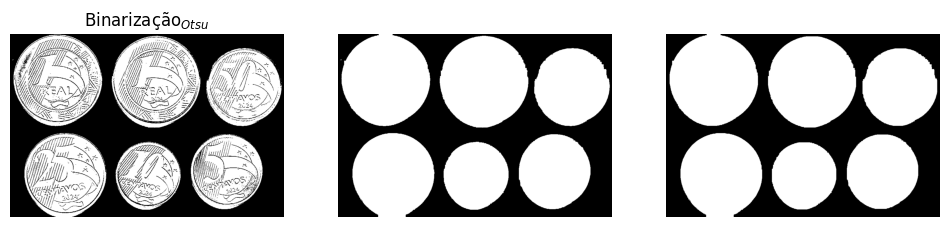

Área detectada na moeda 0: 80883 pixels
Área detectada na moeda 1: 80584 pixels
Área detectada na moeda 2: 58068 pixels
Área detectada na moeda 3: 69189 pixels
Área detectada na moeda 4: 53680 pixels
Área detectada na moeda 5: 43760 pixels


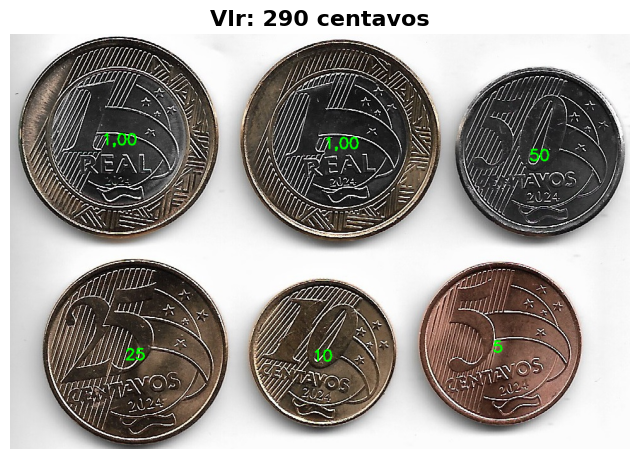

In [ ]:
def processar_e_exibir_moedas(filepath):
    img = mpimg.imread(filepath).astype('uint8')
    img_gray = np.uint8(0.3*img[:,:,0] + 0.59*img[:,:,1] + 0.11*img[:,:,2])

    seg_img = seg_and_postprocessing(img_gray, 15, 31)
    output = cv2.connectedComponentsWithStats(seg_img, 4)
    list_npixels = calc_npixels_label(output[1], output[0])

    soma = 0
    for n, p in enumerate(list_npixels):
        x = int(output[3][n+1][0])
        y = int(output[3][n+1][1])

        # A linha de code abaixo utilizei somente para depurar a área ocupada por cada moeda detectada
        # print(f"moeda {n}:{p}pixels")

        if p < 48720:
            soma += 10
            cv2.putText(img, '10', (x-15, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        elif p >= 48720 and p < 55874:
            soma += 5
            cv2.putText(img, '5', (x-10, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        elif p >= 55874 and p < 63629:
            soma += 50
            cv2.putText(img, '50', (x-15, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        elif p >= 63629 and p < 69326:
            soma += 25
            cv2.putText(img, '25', (x-15, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        else:
            soma += 100
            cv2.putText(img, '1,00', (x-25, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    plt.figure(figsize=(8, 6))

    plt.title(f"Vlr: {soma} centavos", fontsize=16, fontweight='bold')
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    return soma

valor_total = processar_e_exibir_moedas(filename)